# Veri Ön İşleme (Data Preprocessing)

Şimdi işleyeceğimiz bölümün adı veri ön işleme. Veri Bilimde Burası, buradan sonrası ve buradan öncesi için konular şöyle:

1) Veri Manipülasyonu
2) Veri Görselleştirme
3) İstatistik
4) **Veri Ön İşleme** <- We are here
5) Makina Öğrenmesi

Şu an veri ön işlemedeyim, buradan sonra da makina öğrenmesi gelecek. Onları da işledikten sonra Veri Bilimi mevzusunu kapatmış olacağız. Ardından yapay zeka, machine learning, deep learning konularına odaklanabilirim. Veri ön işleme ise makina öğrenmesinin hemen öncesinde yapılan verisetimiz içerisinde gerçekleştirmemiz gereken bazı işlemleri ve dönüşümleri ifade etmektedir.

Veri Ön İşleme (Data Preprocessing) Şunları İçerir:
* Eksik Veri Analizi
* Aykırı Veri Analizi
* Gürültülü (Noisy) Veri Analizi
* Standartlaştırma (Standardization)

Görsel olarak özetlemek gerekirse:

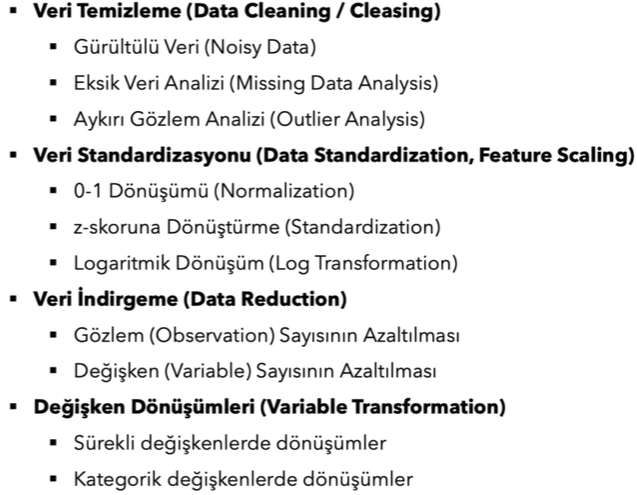

Veri Mi? Model Mi?

* Makina Öğrenmesi **Model**i Amacı: Genellenebilir yapılar ortaya koymaktır. Belirli olaylar gerçekleştiğinde belirli tahmin sonuçları vermektedir.
* **Veri** : Makina Öğrenmesi Modelinin beslendiği yegane şeydir.

# Aykırı Gözlem (Outlier Analysis)

Aykırı Gözlem:
* Dataset'de genel eğilimin oldukça dışına çıkan ya da diğer gözlemlerden oldukça farklı olan gözlemlere aykırı gözlemler denir. Aykırı değeri barındıran gözlem birimine aykırı gözlem denir.

Aykırı Değer:
* Aykırılığı ifade eden sayısal değere ayırı değer denir

--------------------------------------------------------------------

Uğraşacak olduğumuz problemlerin içerisindeki en ciddi problemlerden birisidir.

--------------------------------------------------------------------

Aykırı Değer Neye Sebep Olur:

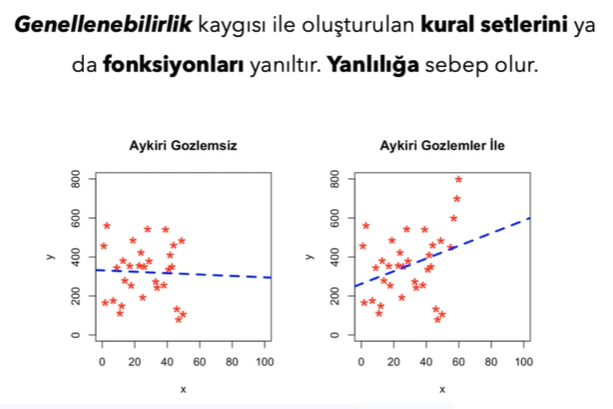

Soldaki grafik ile sağdaki grafik neredeyse aynı. Sadece soldakine 3 adet nokta eklenmiş(en üsttek 3 tane) ve direkt fonksiyonun eğimi değişmiş. Eğitim negatiften pozitife dönmüş. Aykırı gözlemler bu kadar etkiler modelin doğruluğunu

--------------------------------------------------------------------
Kime Göre Neye Göre Aykırı Gözlem?
Aykırı gözlemin tanımına, "verisetinde genel eğilimin dışına çıkan gözlemler" dedik. Peki, verisetinin genel eğiliminin dışına çıkmayı nasıl tanımlarız?

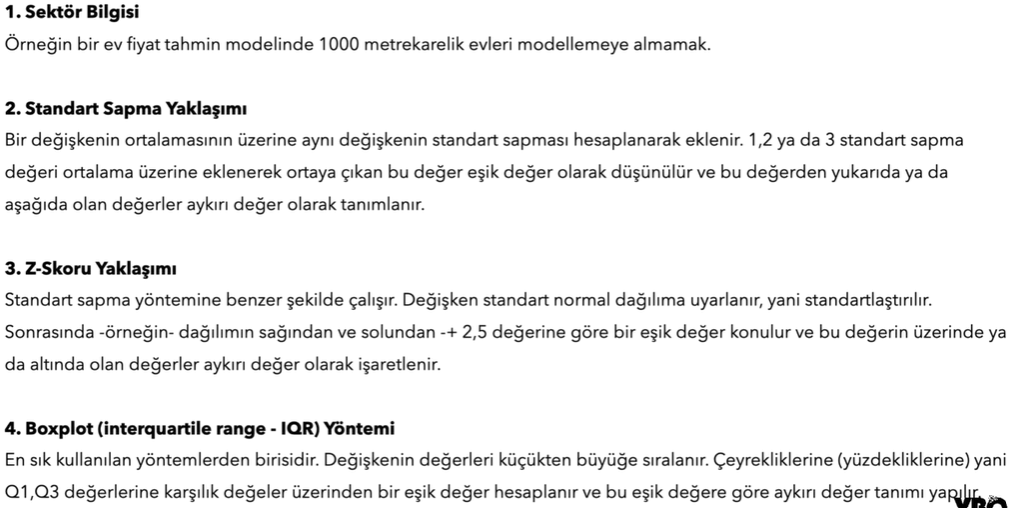

Genellikle 1 ve 3, birlikte tercih edilirse en doğru sonuçlara ulaşılır.

## Aykırı Değerleri Yakalamak

In [7]:
import seaborn as sns

dataset = sns.load_dataset("diamonds")

df = dataset.copy()

df = df.select_dtypes(include=["float","int"]) # veriseti içerisindeki yalnızca sayısal değişkenleri alıyoruz

df = df.dropna() # eksik değerler işimize yaramayacağı için onları atıyoruz

df.head()

,carat,depth,table,price,x,y,z
0,0.23,61.5,55.0,326,3.95,3.98,2.43
1,0.21,59.8,61.0,326,3.89,3.84,2.31
2,0.23,56.9,65.0,327,4.05,4.07,2.31
3,0.29,62.4,58.0,334,4.20,4.23,2.63
4,0.31,63.3,58.0,335,4.34,4.35,2.75


In [8]:
df_table = df["table"]
df_table.head()

0    55.0
1    61.0
2    65.0
3    58.0
4    58.0
Name: table, dtype: float64

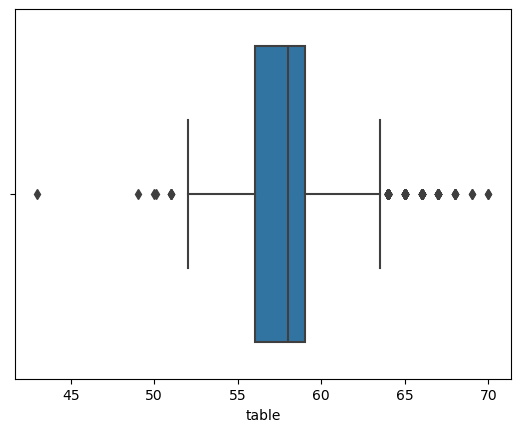

In [9]:
sns.boxplot(x=df_table); 

# görmüş olduğumuz noktalar aykırı değerlerdir

## Aykırı değerleri belirlemek

Verilerin hangisinin aykırı değer olduğunu tanımlamak için bir eşik değer belirlememiz gerekiyor. Yani bu değerin altında ya da üstünde kalan değerlere, bu değer "aykırı değerdir" diyebilmek için. Eşik değerleri de kartilin Q1 ve Q3 değerleri olarak tanımlayacağız.

In [12]:
Q1 = df_table.quantile(0.25)
Q3 = df_table.quantile(0.75)
IQR = Q3-Q1 # inter quartile

In [13]:
Q1

56.0

In [14]:
Q3

59.0

In [15]:
IQR

3.0

In [16]:
alt_sinir = Q1 - 1.5*IQR

# Q1'den IQR'ın 1.5 katının çıkartılmış halini alt eşik değer olarak belirle (51.5)
# Bu da boxplot grafiğindeki kutuların yanklarındaki dikey çizgiler anlamına geliyor "|-box-|" bundaki "|" buralar

In [17]:
ust_sinir = Q3 + 1.5*IQR

# Q3'e IQR'ın 1.5 katını eklemiş halini üst eşik değer olarak belirle (63.5)
# Bu da boxplot grafiğindeki kutuların yanklarındaki dikey çizgiler anlamına geliyor "|-box-|" bundaki "|" buralar

In [18]:
alt_sinir

51.5

In [19]:
ust_sinir

63.5

şimdi, 51.5'dan küçük ve 63.5'dan büyükte yer alan değerleri aykırı değerler olarak ele alacağız

In [21]:
aykiri_alt_tf = df_table[:] < alt_sinir

# df'in içindeki table sütunundaki alt sınırdan küçük olan değerleri getir. (aykırı değerler)

In [22]:
aykiri_ust_tf = df_table[:] > ust_sinir

# df'in içindeki table sütunundaki üst sınırdan büyük olan değerleri getir. (aykırı değerler)

In [23]:
df_table[aykiri_alt_tf] # sadece aykırı olanların indexlerini ve değerlerini getirdi

1515     51.0
3238     50.1
3979     51.0
4150     51.0
5979     49.0
7418     50.0
8853     51.0
11368    43.0
Name: table, dtype: float64

In [24]:
df_table[aykiri_ust_tf] # sadece aykırı olanların indexlerini ve değerlerini getirdi

2        65.0
91       69.0
145      64.0
219      64.0
227      67.0
         ... 
11436    64.0
11437    65.0
11629    65.0
11683    66.0
11757    67.0
Name: table, Length: 187, dtype: float64

In [25]:
df_table[aykiri_ust_tf].index

# sadece aykırıların indexlerini getiri, değerleri yok. bu indexler aracılığıyla düzenleme işlemleri yapabiliriz

Index([    2,    91,   145,   219,   227,   239,   296,   314,   356,   359,
       ...
       10977, 11329, 11341, 11342, 11415, 11436, 11437, 11629, 11683, 11757],
      dtype='int64', length=187)

## Aykırı Değer Problemini Çözmek

3 Farklı Çözüm Çeşidi vardır:
* Silmek
* Ortalamayla Doldurmak
* Baskılamak



### Çözüm 1 : Aykırı Değerleri Silmek

In [29]:
import pandas as pd

df_table = pd.DataFrame(df_table)

In [30]:
df_table.shape

(11813, 1)

In [31]:
t_df = df_table[~((df_table[:] < alt_sinir)| (df_table[:] > ust_sinir)).any(axis=1)] 

# t_df : temiz dataframe ve ~ : de koşulu sağlamayanları al. yani aykırı olmayanları getir

In [32]:
t_df # aykırı değerlerden arındırılmış dataframe

,table
0,55.0
1,61.0
3,58.0
4,58.0
5,57.0
...,...
11808,58.0
11809,60.0
11810,59.0
11811,56.0


### Çözüm 2 : Ortalama ile Doldurma

In [34]:
import seaborn as sns

dataset = sns.load_dataset("diamonds")

df = dataset.copy()

df = df.select_dtypes(include=["float","int"]) # veriseti içerisindeki yalnızca sayısal değişkenleri alıyoruz

df = df.dropna() # eksik değerler işimize yaramayacağı için onları atıyoruz

df.head()

,carat,depth,table,price,x,y,z
0,0.23,61.5,55.0,326,3.95,3.98,2.43
1,0.21,59.8,61.0,326,3.89,3.84,2.31
2,0.23,56.9,65.0,327,4.05,4.07,2.31
3,0.29,62.4,58.0,334,4.20,4.23,2.63
4,0.31,63.3,58.0,335,4.34,4.35,2.75


In [35]:
df_table = df["table"]
df_table.head()

0    55.0
1    61.0
2    65.0
3    58.0
4    58.0
Name: table, dtype: float64

In [36]:
df_table[aykiri_alt_tf].head()

1515    51.0
3238    50.1
3979    51.0
4150    51.0
5979    49.0
Name: table, dtype: float64

In [37]:
df_table.mean()

57.823389486159314

In [38]:
df_table[aykiri_alt_tf] = df_table.mean() # Şu anda aykırı değerler yerine table sütununun ortalamasını yerleştirdik

In [39]:
df_table[aykiri_alt_tf] # görüldüğü üzere aykırı olan değerlerin yerinde table sütununun ortalaması var.

1515     57.823389
3238     57.823389
3979     57.823389
4150     57.823389
5979     57.823389
7418     57.823389
8853     57.823389
11368    57.823389
Name: table, dtype: float64

### Çözüm 3 : Baskılama

Baskılama : Aykırı değerler üst sınırdaysa üst eşik değerine eşitlenir, alt sınırdaysa alt eşik değerine eşitlenir

In [42]:
import seaborn as sns

dataset = sns.load_dataset("diamonds")

df = dataset.copy()

df = df.select_dtypes(include=["float","int"]) # veriseti içerisindeki yalnızca sayısal değişkenleri alıyoruz

df = df.dropna() # eksik değerler işimize yaramayacağı için onları atıyoruz

df.head()

,carat,depth,table,price,x,y,z
0,0.23,61.5,55.0,326,3.95,3.98,2.43
1,0.21,59.8,61.0,326,3.89,3.84,2.31
2,0.23,56.9,65.0,327,4.05,4.07,2.31
3,0.29,62.4,58.0,334,4.20,4.23,2.63
4,0.31,63.3,58.0,335,4.34,4.35,2.75


In [43]:
df_table[aykiri_alt_tf] = Q1 - 1.5*IQR # alt eşik değeri. alt_sinir da yazabilirdik
df_table[aykiri_ust_tf] = Q3 + 1.5*IQR # üst eşik değeri. ust_sinir da yazabilirdik

In [44]:
df_table[aykiri_alt_tf]

1515     51.5
3238     51.5
3979     51.5
4150     51.5
5979     51.5
7418     51.5
8853     51.5
11368    51.5
Name: table, dtype: float64

In [45]:
df_table[aykiri_ust_tf]

2        63.5
91       63.5
145      63.5
219      63.5
227      63.5
         ... 
11436    63.5
11437    63.5
11629    63.5
11683    63.5
11757    63.5
Name: table, Length: 187, dtype: float64

## Çok Değişkenli Aykırı Gözlem Analizi

### Local Outlier Factor (LOF)

Tek Değişkenli aykırı gözlem de boxplot kullandık. Bunda ise Local Outlier Factor yöntemini tercih edeceğiz.

Gözlemleri bulundukları konumda yoğunluk tabanlı skorlayarak buna göre aykırı değer olabilecek değerleri tanıyabilmemize imkan sağlıyor.

Bir noktanın local yoğunluğu bu noktanın komşuları ile karşılaştırılıyor. Eğer bir nokta komşularının yoğunluğundan anlamlı şekilde düşük ise bu nokta komşularından daha seyrek bir bölgede bulunuyordur yorumu yapılabiliyor. Dolayısıyla burada bir komşuluk yapısı söz konusu. Bir değerin çevresi yoğun değilse demek ki bu değer aykırı değerdir şeklinde değerlendiriliyor.

Verilerin kendi sütunların içerisinde mantıklı ancak başka sütunlarla(değişkenlerle) birleştiğinde saçma durum oluşturduğu zaman çok değşkenli aykırı değer olmuş oluyor.

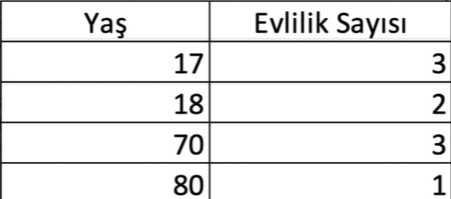

Örneğin burada Yaş değişkeni ve Evlilik sayısı değişkenleri kendi içlerinde mantıklı ancak birleşip bir veriseti oluşturduklarında saçma oluyor. Bir insan 17 yaşında olabilir, hayatı boyunca 3 evlilik de yapmış olabilir ancak eğer 17 yaşında ve 3 evlilik yapmış biriyse, bu hiç alışılagelmedik, aykırı, saçma bir durum ortaya koyar. Bu ihtimal de 0 değil, olabilir ancak bu durum genel veriseti içerisinde hiçbir şeyi temsil etmeyeceği gibi diğer verileri de yanlış bir şekilde etkileyecektir. Bu tarz uç durumları gerçekte yaşanabilecek bir ihtimal bile olsa bu ihtimal çok düşük olduğundan dolayı aykırı değer olarak kabul ederiz.

Bu örneğimizde 17 yaşında 3 kere evlenmiş olan değer A değeri oluyor, kendine benzeri/komşusu/ona yakın olanı yok ya da çok uzakta:

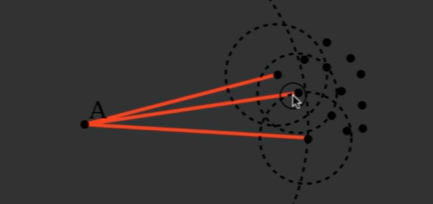

-LOF(Local Outlier Factor) Gösterimi

### Çözüm 1 : Aykırı Değerleri Silmek

In [51]:
import seaborn as sns

dataset = sns.load_dataset("diamonds")

df = dataset.copy()

df = df.select_dtypes(include=["float","int"]) # veriseti içerisindeki yalnızca sayısal değişkenleri alıyoruz

df = df.dropna() # eksik değerler işimize yaramayacağı için onları atıyoruz

df.head()

,carat,depth,table,price,x,y,z
0,0.23,61.5,55.0,326,3.95,3.98,2.43
1,0.21,59.8,61.0,326,3.89,3.84,2.31
2,0.23,56.9,65.0,327,4.05,4.07,2.31
3,0.29,62.4,58.0,334,4.20,4.23,2.63
4,0.31,63.3,58.0,335,4.34,4.35,2.75


In [52]:
import numpy as np
from sklearn.neighbors import LocalOutlierFactor

In [53]:
clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)

In [54]:
clf.fit_predict(df)

array([-1, -1, -1, ...,  1,  1,  1])

In [55]:
df_scores = clf.negative_outlier_factor_

In [56]:
df_scores[0:10]

array([-1.25828131, -1.26933664, -1.29331959, -1.05525469, -1.03691404,
       -1.01846075, -1.01861874, -1.00440223, -1.01857701, -1.01391585])

In [57]:
np.sort(df_scores)[:10]

# Burada gördük ki değerler birbirlerine yakın ancak eğer biri çok uzakta olsaydı, ona kadar olan değerleri bir yere, o nu başka bir yere atacaktık. 
# Yani o değere kadar olan değerleri eşik değer olarak belirleyecektik. Burada da yapacağız şimdi

array([-4.37081214, -4.29842288, -3.40044967, -3.35007989, -3.29322345,
       -3.18715386, -2.86404215, -2.74570485, -2.68516533, -2.62781429])

In [58]:
np.sort(df_scores[:])[13]  # burayı eşik değer olarak kabul ettik. Buna göre işlemleri gerçekleştirelim

-2.393551385777494

In [59]:
esik_deger = np.sort(df_scores[:])[13] # 13.elemanı eşik değer olarak kaydettik

In [60]:
aykiri_tf = df_scores > esik_deger # belirlediğimiz eşik değerden yüksek olanları aykırı değer olarak tanımladık

In [61]:
aykiri_tf

array([ True,  True,  True, ...,  True,  True,  True])

In [62]:
yeni_df = df[df_scores < esik_deger] # yeni dataframe'imizde aykırı değerler yok
yeni_df.head() # aykırı değersiz dataframe'i göster

,carat,depth,table,price,x,y,z
91,0.86,55.1,69.0,2757,6.45,6.33,3.52
314,0.76,59.0,70.0,2800,5.89,5.80,3.46
359,0.74,61.1,68.0,2805,5.82,5.75,3.53
777,0.75,55.8,70.0,2859,6.09,5.98,3.37
1275,0.99,58.0,67.0,2949,6.57,6.50,3.79


### Çözüm 2 : Baskılamak

In [64]:
esik_deger_satiri = df[df_scores == esik_deger] # bu bizim eşik değerimiz
esik_deger_satiri

,carat,depth,table,price,x,y,z
712,0.98,53.3,67.0,2855,6.82,6.74,3.61


**ÖNEMLİ NOT!!!!**

Tek Değişkenli Aykırı gözlemdeki gibi 

df_table[aykiri_ust_tf] = Q3 + 1.5*IQR 

şeklinde yapamıyoruz çünkü burada çok değişkenlileri inceliyoruz ve çok değişkenli demek, çok satır demek, index sayıları demek. Bu sebeple direkt 

df[df_scores > esik_deger] = df[df_scores == esik_deger]


eşitleyincetüm değerler NaN oluyor çünkü index numaraları vs karışıyor. burada tek bir değeri eşitlemiyoruz, tüm satırı eşitliyoruz 

In [66]:
aykiri_degerler_satirlari = df[df_scores < esik_deger]
aykiri_degerler_satirlari

,carat,depth,table,price,x,y,z
91,0.86,55.1,69.0,2757,6.45,6.33,3.52
314,0.76,59.0,70.0,2800,5.89,5.80,3.46
359,0.74,61.1,68.0,2805,5.82,5.75,3.53
777,0.75,55.8,70.0,2859,6.09,5.98,3.37
1275,0.99,58.0,67.0,2949,6.57,6.50,3.79
4518,1.00,43.0,59.0,3634,6.32,6.27,3.97
6341,1.00,44.0,53.0,4032,6.31,6.24,4.12
8014,1.50,70.1,58.0,4328,6.96,6.85,4.84
8186,1.50,71.3,58.0,4368,6.85,6.81,4.87
8392,0.50,69.8,55.0,584,4.89,4.80,3.38


şimdi atama işlemini yapmak için dataframeleri indexsiz arraylere çevirmemiz lazım 

In [68]:
indexsiz_aykiri_arrayleri = aykiri_degerler_satirlari.to_records(index=False) # aykırı değişkenleri indekxsizleştirdik

In [69]:
indexsiz_aykiri_arrayleri[:] = esik_deger_satiri.to_records(index=False) # eşik değeri indexsizleştirip aykırılara atadık

In [70]:
df[df_scores > esik_deger] = pd.DataFrame(indexsiz_aykiri_arrayleri, index=df[df_scores > esik_deger].index)

ValueError: Length of values (13) does not match length of index (11799)

In [ ]:
# bu kısmı yapamadım. hoca sik gibi anlatmış. 237.video olan Baskılama Yöntemi videosuna tekrar bak istersen. 

# Eksik Veri

Üzerinde çalışılan verilerde eksiklik olması durumunu ifade etmektedir.

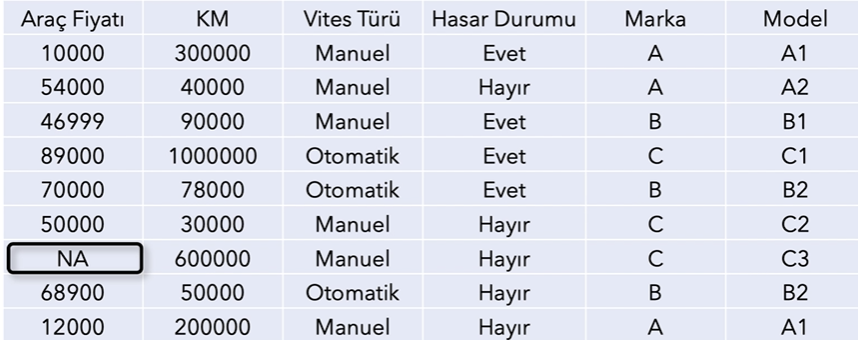

Eksik veri böyle gözükür. NaN, Na, Null gibi görünür.

------------------------------------------------------------------------

Bu eksik verinin olduğu satırı komple silebilir ya da orayı doldurabiliriz. Ancak her iki yöntemin de kendine has sorunları vardır.

------------------------------------------------------------------------

**Eksik Verinin Olduğu Satırı Silmek:**

* Eksik değere sahip gözlemlerin(satırların) verisetinden direkt çıkarılması ve rassallığının incelenmemesi, yapılacak istatistiksel çıkarımların ve modelleme çalışmalarının güvenilirliğini düşürecektir.
* Eksiklikler eğer rastgele oluşmuş ise o veri satırını silmek doğrudur, eğer yapısal problemlerden dolayı meydana gelmiş ise bu eksiklikler, silinmemesi gerekir

------------------------------------------------------------------------

Verisetindeki eksikliğe nasıl yaklaşmak gerekir?
* Verisetindeki eksikliğin yapısal bir eksiklik olup olmadığının bilinmesi gerekir. Eğer yapısalsa doldurulmaması gerek. (Yapısal eksiklik : bilinçli şekilde doldurulmadıysa ya da boş demek sıfır demekse)
* Na her zaman eksiklik anlamına gelmez (kredi kartı olduğu bilinen birinde harcama Na gözüküyorsa bu bir eksik olmaktan ziyade, daha harcama yapmamış olabilir örneğin. Burada Na, sıfır yerine geçmiş)
* Bilgi kaybı (1 değerin 100 tane değişkeninin 99'u dolu, 1'i boş ise, sırf bu boş yüzünden 99 faydalı bilgiyi kaybetmek uğruna silme yapılmamalı)

------------------------------------------------------------------------
Eksik Veri Türleri:
* Tümüyle Rastlantısal Kayıp : Diğer değişkenlerden ya da yapısal yapısal bir problemden kaynaklanmayan tamamen rastgele oluşan gözlemler (Silinebilir / Atama yapılabilir)
* Rastlantısal Kayıp : Diğer değişkenlere bağlı olarak oluşabilen eksiklik türü
* Rastlantısal Olmayan Kayıp : Göz ardı edilemeyecek olan ve yapısal problemler ile ortaya çıkan eksiklik türü

------------------------------------------------------------------------
Eksik Verinin Rassallığı Testi:
* Görsel Teknikler
* Bağımsız İki Örneklem T Testi
* Korelasyon Testi
* Little'ın MCAR Testi

Burada en çok birinci ve sonuncu kullanılır.

------------------------------------------------------------------------
Eksik Veri Problemi Nasıl Giderilir?
* Silme Yöntemleri
   * Gözlem ya da Değişken Silme Yöntemi
   * Liste Bazında Silme Yöntemi (Listwise Method)
   * Çiftler Bazında Silme Yöntemi (Pairwise Method)
 

* Değer Atama Yöntemleri
   * Ortanca, Ortalama, Medyan
   * En Benzer Birimine Atama (hot deck)
   * Dış Kaynaklı Atama

 
* Tahmine Dayalı Yöntemler
   * Makina Öğrenmesi
   * EM
   * Çoklu Atama Yöntemi

## Eksik Veri Hızlı Çözüm

In [ ]:
import numpy as np
import pandas as pd
V1 = np.array([1,3,6,np.NaN,7,1,np.NaN,9,15])
V2 = np.array([7,np.NaN,5,8,12,np.NaN,np.NaN,2,3])
V3 = np.array([np.NaN,12,3,6,14,7,np.NaN,2,31])
df = pd.DataFrame({
    "V1" : V1,
    "V2" : V2,
    "V3" : V3}
)

df # eksik veriler içeren 8x3'lük bir dataframe oluşturduk

In [ ]:
df.isnull().sum() # her bir sütunun içerdiği eksik veri sayısını sütun ismiyle birlikte verir

In [ ]:
df.notnull().sum() # her bir sütunun içerdiği eksik olmayan veri sayısını sütun ismiyle birlikte verir

In [ ]:
df.isnull().sum().sum() # tüm nulların sayısını sütunların ismini vermeden tekte söyler

In [ ]:
df[df.isnull().any(axis=1)] # kendisinde en az 1 tane eksik veri barındıran satırları getirir

In [ ]:
df[df.notnull().all(axis=1)] # kendisinde hiç eksik veri barındırmayan satırları getirir

In [ ]:
df[df["V1"].notnull() & df["V2"].notnull() & df["V3"].notnull()] # bir önceki satırın aynısı, manuel axissiz

In [ ]:
# eksik değerlerin direkt silinmesi:

In [ ]:
df.dropna() # verisetindeki tüm eksiklikleri siler. bir satırda 1 tane bile eksik varsa satırı komple uçuruyor

In [ ]:
# eksik değerlere değer atama: 

In [ ]:
df["V1"].mean()

In [ ]:
df["V1"].fillna(df["V1"].mean()) # V1 sütunu içerisindeki eksik değerleri V1 sütununun ortalamasıyla doldur

In [ ]:
df["V2"].fillna(0) # V2 sütunu içerisindeki eksik değerleri sıfır ile doldur

In [ ]:
df["V3"].fillna("burası boş") # V3 sütunu içerisindeki eksik değerleri "burası boş" ifadesiyle doldur

## Eksik Veri Yapısının Görselleştirilmesi

In [ ]:
import sys
!{sys.executable} -m pip install missingno

import missingno as msno

In [ ]:
msno.bar(df); 

# içlerinde kaç tane tam değer olduğu en üstte, kaç tane olması gerektiği sol en üstteki 1 değerine karşılık gelen sağdaki rakamda yazar.
# Bu örnek için V1'de 2 tane, V2'de 3 tane, V3'de 2 tane eksik değer var

In [ ]:
msno.matrix(df);

# Eksik değerlerin rassallığıylaa ilgili gerekli yapısak bozuklukları yakalayabilme imkanı veren bir görsel

In [ ]:
import seaborn as sns

dataset = sns.load_dataset("planets") # daha çok eksik veri üzerinde bu kütüpleri çalıştırmak için bunu import ettik

df = dataset.copy()

df.head()

In [ ]:
df.isnull().sum()

In [ ]:
msno.matrix(df); 

# görseli iyi incelersek ne zaman orbital_periodda null değer olsa, masste de olmuş. mass, orbital_perioda bağımlı
# rassallığı inceliyorduk ve buraya baktıktan sonra "hmmm burada değişkenler arası bağımlılık söz konusu" çıkarımını yapabildik görsel sayesinde
# yani bu veriseti üzerinde boş değerlerde silme ya da değer atama işlemlerinde bulunmak bazı sorunları da beraberinde getirecektir

In [ ]:
msno.heatmap(df);

# bu bize çok değerli bir şey olan nullability correlation'u sunuyor. yani boşluk ilişkisi. Yani gidip, biri boşken diğeri boş olmuş mu diye bakıyor
# ve sunduğu grafik ile sayısal olarak hangisi hangisine bağımlı anlayabiliyoruz. -1 ile 1 arasında değerler sunuyor.
# örneğin eğer mass ile orbital_peridun kesiştiği yerde -0.8 yazıyorsa bu aralarında negatif korelasyon var demektir
# 0.4 yazıyorsa pozitif korelasyon var demektir

## Eksik Verileri Silme Yöntemleri

In [ ]:
import numpy as np
import pandas as pd
V1 = np.array([1,3,6,np.NaN,7,1,np.NaN,9,15])
V2 = np.array([7,np.NaN,5,8,12,np.NaN,np.NaN,2,3])
V3 = np.array([np.NaN,12,3,6,14,7,np.NaN,2,31])
df = pd.DataFrame({
    "V1" : V1,
    "V2" : V2,
    "V3" : V3}
)

df # eksik veriler içeren 8x3'lük bir dataframe oluşturduk

In [ ]:
df.dropna() # tüm eksikleri sil. kalıcı olması için argüman olarak inplace=True

In [ ]:
df.dropna(how="all") # sadece satırın tamamı null'dan oluşanları sil

In [ ]:
df.dropna(axis=1) # en az 1 tane null içeren tüm sütunları sil

In [ ]:
df.dropna(axis=1, how="all") # sadece tüm sütun boyunca null içeren sütunları sil

## Değer Atama Yöntemleri

In [ ]:
import numpy as np
import pandas as pd
V1 = np.array([1,3,6,np.NaN,7,1,np.NaN,9,15])
V2 = np.array([7,np.NaN,5,8,12,np.NaN,np.NaN,2,3])
V3 = np.array([np.NaN,12,3,6,14,7,np.NaN,2,31])
df = pd.DataFrame({
    "V1" : V1,
    "V2" : V2,
    "V3" : V3}
)

df # eksik veriler içeren 8x3'lük bir dataframe oluşturduk

### Sayısal Değişkenlerde Değer Atama

In [ ]:
df["V1"].fillna(0)

In [ ]:
df["V1"].fillna(df["V1"].mean())

In [ ]:
df.apply(lambda x:x.fillna(x.mean()), axis=0) # tüm değişkenlerdeki boş yerleri kendi ortalamalarıyla doldur

In [ ]:
df.fillna(df.mean()) # bir önceki hücrenin farklı yazılışı. aynı işlev

In [ ]:
df.where(pd.notna(df), df.mean(), axis="columns") # son 2 hücre ile aynı işlem

### Kategorik Değişkenlerde Değer Atama

Şirkette çalışan kişilerin bilgilerinin olduğu bir veriseti hayal edelim. Bu verisetindeki bir kişinin maaşı eksik olsun. Maaş değişkeni sayısal bir değişken olduğu için bunu nasıl doldurabileceğimizi öğrendik. Ancak bu kişi maaş seviyesi şirketin diğer departmanlarından çok daha yüksek ya da çok daha düşük bir departmanda çalışıyorsa tüm şirketteki çalışan kişilerin maaş ortalamasını buna vermek yanlış olacak. Biz de burada kategorik değişkenleri daha da indirgeyerek çalışmaya çalışıcaz. Yani örneğin departmanlara göre maaşların ortalamasını alıp o kişinin departmanının ortalamasını o kişiye verebiliriz, bu sayede çok daha ince ayar yapmış oluruz.

In [ ]:
V1 = np.array([1,3,6,np.NaN,7,1,np.NaN,9,15])
V2 = np.array([7,np.NaN,5,8,12,np.NaN,np.NaN,2,3])
V3 = np.array([np.NaN,12,5,6,14,7,np.NaN,2,31])
V4 = np.array(["IT","IT","IK","IK","IK","IK","IK","IT","IT"])

df = pd.DataFrame(
    {"maas" : V1,
     "V2" : V2,
     "V3" : V3,
     "departman" : V4}
)

df

In [ ]:
df[df["departman"] == "IK"]["maas"].fillna(df[df["departman"] == "IK"]["maas"].mean())

# IK departmanının içerisindeki maaşlardan eksik olanları, IK departmanının maaş ortalamasıyla doldur

In [ ]:
df[df["departman"] == "IT"]["maas"].fillna(df[df["departman"] == "IK"]["maas"].mean())

# IT departmanının içerisindeki maaşlardan eksik olanları, IT departmanının maaş ortalamasıyla doldur

### Kategorik Değişkenlerdeki Eksikliklere Değer Atama

In [ ]:
V1 = np.array([1,3,6,np.NaN,7,1,np.NaN,9,15])
V4 = np.array(["IT",np.NaN,"IK","IK","IK","IK","IK","IT","IT"], dtype="object")

df = pd.DataFrame(
    {"maas" : V1,
     "departman" : V4}
)

df

In [ ]:
# Kategorik değişkenlerde değer atamada en kullanışlı yöntem mode() işlemidir. İlgili kategoride en sık gözlenen terim neyse o değeri atamaktır

df["departman"].fillna(df["departman"].mode()[0])

In [ ]:
# Kategorik değişkenlerde bir diğer değer atamada yöntemi de ffill() ya da bfill(). bu, ilgili null'dan öncesi veya sonrasındaki atamamamızı sağlar

df["departman"].bfill() # sonrasındaki değerlerle doldur

In [ ]:
df["departman"].ffill() # öncesindeki değerlerle doldur

### Tahmine Dayalı Değer Atama (KNN & Random Forest & EM)

Normalde eksik değerleri ya silerdik ya da değer atardık. Bu değer atama işlemini de mean, median, sum gibi işlemlerle gerçekleştirirdik. Burada yine eksik değerleri doldurma ile ilgileneceğiz ancak bu eksik değerleri makina öğrenmesi algoritmalarıyla doldurma işlemini gerçekleştireceğiz. Elimizdeki eksik değer, makina öğrenmesi modelinin diğer değişkenleri incelemesi sonucu çıkan değer ile doldururlur. Ancak bu algoritmaları kullanacak olsak bile, öncesinde eksik değerleri gözlemlemek, neden olduğunu anlamak, yapısal mı değil mi belirlemek ve ondan sonra doldurmaya karar verince bunları kullanmak yine aynı oranda önem arz ediyor

In [75]:
import seaborn as sns
import missingno as msno

dataset = sns.load_dataset("titanic")

df = dataset.copy()

df = df.select_dtypes(include=["int","float"])

print(df.head())

df.isnull().sum()

   survived  pclass   age  sibsp  parch     fare
0         0       3  22.0      1      0   7.2500
1         1       1  38.0      1      0  71.2833
2         1       3  26.0      0      0   7.9250
3         1       1  35.0      1      0  53.1000
4         0       3  35.0      0      0   8.0500


survived      0
pclass        0
age         177
sibsp         0
parch         0
fare          0
dtype: int64

In [78]:
import sys
!{sys.executable} -m pip install ycimpute

#### KNN ile Eksik Değer Doldurma

In [121]:
from ycimpute.imputer import knnimput

In [123]:
var_names = list(df) # knn bizden numpy arrayi beklediği için dataframe içindeki değişken isimlerini listeye çevirdik

In [125]:
n_df = np.array(df) # knn bizden numpy arrayi beklediği için listeyi numpy arrayine çevirdik

In [127]:
n_df[:10]

array([[ 0.    ,  3.    , 22.    ,  1.    ,  0.    ,  7.25  ],
       [ 1.    ,  1.    , 38.    ,  1.    ,  0.    , 71.2833],
       [ 1.    ,  3.    , 26.    ,  0.    ,  0.    ,  7.925 ],
       [ 1.    ,  1.    , 35.    ,  1.    ,  0.    , 53.1   ],
       [ 0.    ,  3.    , 35.    ,  0.    ,  0.    ,  8.05  ],
       [ 0.    ,  3.    ,     nan,  0.    ,  0.    ,  8.4583],
       [ 0.    ,  1.    , 54.    ,  0.    ,  0.    , 51.8625],
       [ 0.    ,  3.    ,  2.    ,  3.    ,  1.    , 21.075 ],
       [ 1.    ,  3.    , 27.    ,  0.    ,  2.    , 11.1333],
       [ 1.    ,  2.    , 14.    ,  1.    ,  0.    , 30.0708]])

In [129]:
n_df.shape

(891, 6)

In [131]:
dff = knnimput.KNN(k=4).complete(n_df) # n_df içerisindeki eksik değerleri KNN algoritması yardımıyla doldurdu

Imputing row 1/891 with 0 missing, elapsed time: 0.189
Imputing row 101/891 with 0 missing, elapsed time: 0.192
Imputing row 201/891 with 0 missing, elapsed time: 0.193
Imputing row 301/891 with 1 missing, elapsed time: 0.195
Imputing row 401/891 with 0 missing, elapsed time: 0.197
Imputing row 501/891 with 0 missing, elapsed time: 0.198
Imputing row 601/891 with 0 missing, elapsed time: 0.199
Imputing row 701/891 with 0 missing, elapsed time: 0.199
Imputing row 801/891 with 0 missing, elapsed time: 0.201


In [132]:
type(dff) # dff şu anda numpy arrayi, onu pandas dataframe'ine çevirmemiz gerekiyor

numpy.ndarray

In [135]:
var_names

['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

In [137]:
dff = pd.DataFrame(dff, columns = var_names)

In [139]:
type(dff)

pandas.core.frame.DataFrame

In [143]:
dff.isnull().sum() # KNN gitti ve tüm değerleri doldurdu

survived    0
pclass      0
age         0
sibsp       0
parch       0
fare        0
dtype: int64

#### Random Forest ile Eksik Değer Doldurma

In [148]:
import seaborn as sns
import missingno as msno

dataset = sns.load_dataset("titanic")

df = dataset.copy()

df = df.select_dtypes(include=["int","float"])

print(df.head())

df.isnull().sum()

   survived  pclass   age  sibsp  parch     fare
0         0       3  22.0      1      0   7.2500
1         1       1  38.0      1      0  71.2833
2         1       3  26.0      0      0   7.9250
3         1       1  35.0      1      0  53.1000
4         0       3  35.0      0      0   8.0500


survived      0
pclass        0
age         177
sibsp         0
parch         0
fare          0
dtype: int64

In [150]:
df.isnull().sum()

survived      0
pclass        0
age         177
sibsp         0
parch         0
fare          0
dtype: int64

In [152]:
var_names = list(df) # Random Forest bizden numpy arrayi beklediği için dataframe içindeki değişken isimlerini listeye çevirdik

In [154]:
n_df = np.array(df) # Random Forest bizden numpy arrayi beklediği için listeyi numpy arrayine çevirdik

In [127]:
n_df[:10]

array([[ 0.    ,  3.    , 22.    ,  1.    ,  0.    ,  7.25  ],
       [ 1.    ,  1.    , 38.    ,  1.    ,  0.    , 71.2833],
       [ 1.    ,  3.    , 26.    ,  0.    ,  0.    ,  7.925 ],
       [ 1.    ,  1.    , 35.    ,  1.    ,  0.    , 53.1   ],
       [ 0.    ,  3.    , 35.    ,  0.    ,  0.    ,  8.05  ],
       [ 0.    ,  3.    ,     nan,  0.    ,  0.    ,  8.4583],
       [ 0.    ,  1.    , 54.    ,  0.    ,  0.    , 51.8625],
       [ 0.    ,  3.    ,  2.    ,  3.    ,  1.    , 21.075 ],
       [ 1.    ,  3.    , 27.    ,  0.    ,  2.    , 11.1333],
       [ 1.    ,  2.    , 14.    ,  1.    ,  0.    , 30.0708]])

In [129]:
n_df.shape

(891, 6)

In [164]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

# Eksik değer içeren veri çerçevesi: n_df
imputer = IterativeImputer(estimator=RandomForestRegressor(), random_state=0)
dff = imputer.fit_transform(n_df)

C:\Users\since\anaconda3\Lib\site-packages\sklearn\impute\_iterative.py:785: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [166]:
dff = pd.DataFrame(dff, columns=var_names)

In [168]:
dff.isnull().sum()

survived    0
pclass      0
age         0
sibsp       0
parch       0
fare        0
dtype: int64

#### EM ile Eksik Değer Doldurma

In [197]:
import seaborn as sns
import missingno as msno

dataset = sns.load_dataset("titanic")

df = dataset.copy()

df = df.select_dtypes(include=["int","float"])

print(df.head())

df.isnull().sum()

   survived  pclass   age  sibsp  parch     fare
0         0       3  22.0      1      0   7.2500
1         1       1  38.0      1      0  71.2833
2         1       3  26.0      0      0   7.9250
3         1       1  35.0      1      0  53.1000
4         0       3  35.0      0      0   8.0500


survived      0
pclass        0
age         177
sibsp         0
parch         0
fare          0
dtype: int64

In [199]:
from ycimpute.imputer import EM

In [201]:
var_names = list(df)
n_df = np.array(df)

In [203]:
dff = EM().complete(n_df) # Bir Makina Öğrenmesi algoritması olan EM algoritmasıyla eksik değerleri doldurmuş olduk

In [204]:
dff = pd.DataFrame(dff, columns=var_names)

In [206]:
dff.isnull().sum() # Görüldüğü üzere eksik değer yok

survived    0
pclass      0
age         0
sibsp       0
parch       0
fare        0
dtype: int64

# Veri Standardizasyonu / Veri Dönüşümü

Veri Standardizasonu ve Veri dönüşümü karıştırılan kavramlardır.

Ortak Yanlar:
* İkisi de veri üzerindeki dönüştürme işlemini ifade eder

Veri Standardizasyonu:
* Değişkenin kendi içerisindeki varyans yapısı, bilgi yapısı bozulmaz, belirli bir standardizasyona oturtulur
* Değişkenin değerleri değişir; ortalama, standart sapma, varyans gibi değerleri değişir ancak taşımış olduğu yayılım, dağılım bilgisinin özütü değişmez

Veri Dönüşünümü:
* Taşınan bilginin yapısı, özütü bozulur
* Dönüştürülen değişkenin taşıdğını bilginin, taşındığı şekliyle kalamaması, dönüştürülmesi demektir
* Örneğin cinsiyet değişkenindeki kadın erkek değerlerinin 0, 1 değerlerine dönüştürülmesi gibi
* Bilgi değişmez ama bilginin yapısı değişmiş olur
* Veri yapısını bazen bozar, bazen dönüştürmüş olur

## Değişken/Veri Standardizasyonu

In [223]:
import numpy as np
import pandas as pd

V1 = np.array([1,3,6,5,7])
V2 = np.array([7,7,5,8,12])
V3 = np.array([6,12,5,6,14])

df = pd.DataFrame(
    {"V1" : V1,
     "V2" : V2,
     "V3" : V3})

df = df.astype(float)
df

,V1,V2,V3
0,1.0,7.0,6.0
1,3.0,7.0,12.0
2,6.0,5.0,5.0
3,5.0,8.0,6.0
4,7.0,12.0,14.0


### Standardizasyon

In [249]:
from sklearn import preprocessing

In [251]:
df

,V1,V2,V3
0,1.0,7.0,6.0
1,3.0,7.0,12.0
2,6.0,5.0,5.0
3,5.0,8.0,6.0
4,7.0,12.0,14.0


In [253]:
preprocessing.scale(df) 

# standartlaştırma işlemi yapıldı
# df'i dönüştür demek. Veri seti içerisindeki değerlerin tamamı, kendi belirlediği sayılarla temsil ediliyor artık
# verilerin hepsine bu işlemi yaptığından dolayı, hepsine standart bir dönüşüm uyguladığından dolayı 
# yapıların birbirleriyle kıyaslanabilirliği bozulmamış oldu
# makina öğrenmesi algoritmaları, birbirlerinden farklı yapılardaki değerleri sevmezler, bu sebeple standartlaştırma işlemi yapılır,
# verilerin tamamı bir temsil setine dönüştürülür

array([[-1.57841037, -0.34554737, -0.70920814],
       [-0.64993368, -0.34554737,  0.92742603],
       [ 0.74278135, -1.2094158 , -0.98198051],
       [ 0.27854301,  0.08638684, -0.70920814],
       [ 1.2070197 ,  1.81412369,  1.47297076]])

### Normalizasyon

Değerleri 0 ile 1 arasına dönüştürmek için kullanılır

In [256]:
preprocessing.normalize(df)

array([[0.10783277, 0.75482941, 0.64699664],
       [0.21107926, 0.49251828, 0.84431705],
       [0.64699664, 0.53916387, 0.53916387],
       [0.4472136 , 0.71554175, 0.53665631],
       [0.35491409, 0.60842415, 0.70982818]])

### Min-Max Dönüşümü

Değerleri belirlemiş olduğumuz iki değer arasında dönüştürmek için kullanılır

In [265]:
scaler = preprocessing.MinMaxScaler(feature_range = (10,20)) # burada hangi 2 değer arasına dönüştüreceğimiz söyledik

In [269]:
scaler.fit_transform(df) # dönüştürme işlemini yaptık

array([[10.        , 12.85714286, 11.11111111],
       [13.33333333, 12.85714286, 17.77777778],
       [18.33333333, 10.        , 10.        ],
       [16.66666667, 14.28571429, 11.11111111],
       [20.        , 20.        , 20.        ]])

## Değişken/Veri Dönüşümleri

Dönüşümler > Standardizasyon. Yani her bir standardizasyon bir değişken dönüşümüdür. Dönüşümlerde mevcut datasetin yapısını bozuyor muyuz bozmuyor muyuz, buna bakmak lazım

In [274]:
import seaborn as sns

dataset = sns.load_dataset("tips")

df = dataset.copy()

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 0-1 Dönüşümü

Örneğin datasetimizdeki cinsiyet değerlerini 1 ve sıfırlara dönüştürmek demek. Bu dönüşüm, **labelencoder** isimli bir fonksiyonla yapılıyor ve bu dünyadaki en sık kullanılan dönüşümlerden birisi

In [283]:
from sklearn.preprocessing import LabelEncoder

In [293]:
lbe = LabelEncoder()

df["yeni_sex"] = lbe.fit_transform(df["sex"])

df["yeni_sex"] 

# Male Female değerlerinin içinde bulunduğu sex sütununu 0 ve 1 lerden oluşan bir sütun olarak yeni bir sütunda oluşturduk
# burada sık yapılan bir hata olarak: 0'ın hangi değere, 1'in hangi değere geleceğini kendi belirliyor, bu sebeple hangisi hangisine gitmiş kontrol et

0      0
1      1
2      1
3      1
4      0
      ..
239    1
240    0
241    1
242    1
243    0
Name: yeni_sex, Length: 244, dtype: int32

In [297]:
df # yeni oluşturulan sütunu görebiliriz

,total_bill,tip,sex,smoker,day,time,size,yeni_sex
0,16.99,1.01,Female,No,Sun,Dinner,2,0
1,10.34,1.66,Male,No,Sun,Dinner,3,1
2,21.01,3.50,Male,No,Sun,Dinner,3,1
3,23.68,3.31,Male,No,Sun,Dinner,2,1
4,24.59,3.61,Female,No,Sun,Dinner,4,0
...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,1
240,27.18,2.00,Female,Yes,Sat,Dinner,2,0
241,22.67,2.00,Male,Yes,Sat,Dinner,2,1
242,17.82,1.75,Male,No,Sat,Dinner,2,1


### "1 ve Diğerleri (0) Dönüşümü"

Örneğin verisetimiz içerisinde birden fazla sınıf var, bunların bir tanesine bir, kalanlarına sıfır verme durumu

In [303]:
df.head() # buradaki time, ya da day değişkeni için bu dönüşüm gerçekleştirilebilir

,total_bill,tip,sex,smoker,day,time,size,yeni_sex
0,16.99,1.01,Female,No,Sun,Dinner,2,0
1,10.34,1.66,Male,No,Sun,Dinner,3,1
2,21.01,3.50,Male,No,Sun,Dinner,3,1
3,23.68,3.31,Male,No,Sun,Dinner,2,1
4,24.59,3.61,Female,No,Sun,Dinner,4,0


In [311]:
df["yeni_day"] = np.where(df["day"].str.contains("Sun"),1,0) 

# dataframe'imiz içerisindeki day sütununun içerisinde eğer Sun değeri varsa buna 1 de, kalanlarına sıfır de
# yani pazar gününe 1 dedik, p.tesi, salı, çarş, perş, cum, ctesi günlerine sıfır

In [313]:
df

,total_bill,tip,sex,smoker,day,time,size,yeni_sex,yeni_day
0,16.99,1.01,Female,No,Sun,Dinner,2,0,1
1,10.34,1.66,Male,No,Sun,Dinner,3,1,1
2,21.01,3.50,Male,No,Sun,Dinner,3,1,1
3,23.68,3.31,Male,No,Sun,Dinner,2,1,1
4,24.59,3.61,Female,No,Sun,Dinner,4,0,1
...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,1,0
240,27.18,2.00,Female,Yes,Sat,Dinner,2,0,0
241,22.67,2.00,Male,Yes,Sat,Dinner,2,1,0
242,17.82,1.75,Male,No,Sat,Dinner,2,1,0


### Çok Sınıflı Dönüşüm

Diğerlerinde olduğu gibi, bir kategorik değişkenin içerisindeki sınıflar başka başka değerlere dönüştürülür

In [331]:
from sklearn.preprocessing import LabelEncoder

In [333]:
lbe = LabelEncoder()

In [335]:
lbe.fit_transform(df["day"])

# 0'dan 3'e kadar, perş cum ctesi pazar günlerinin her birini temsil eden rakamlar atadı

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 3])

**Çok Önemli!!!!:** Çok fazla değeri olan bir kategorik değişkenin değerlerinin sayısı arttıkça bu rakamlar da artacağı için, biz bu değerleri machine larning modeline verdiğimizde bunları bir rakam olarak aldığı zaman, rakamların arasında büyüklük küçüklük muhabbeti olacağı için bağımlı değişkenleriyle olan ilişkisi komple bozulmuş olacak. Yani nomianal olan, değerleri arasında fark olmayan bir kategorik değişkenin değerleri rakama çevrilince sanki ordinalmiş gibi algılanabilir ve bu da çok fazla yanlılık, noise, hatalı çıkarımlara sebep olabilmektedir ve algoritmaları şaşırtmakta ve accuracylerini yerle bir etmektedir. Çoooook önemli bir kısım bu not. Bu durumda **one-hot encoding** yapacağız:

## One-Hot Dönüşümü ve Dummy Değişken Tuzağı

Bir kategorik değişkenin numerik temsillere dönüştürüldükten sonra çıkan büyüklük küçüklük problemini gidermek için vardır. Nominallerin sanki ordinalmiş gibi algılanmasına engel olur. Yani elimizde bir kategorik değişken varsa bunu numerik bir değere dönüştüreceğimiz zaman kullanacağımız bir yaklaşımdır one-hot.

In [354]:
import seaborn as sns

dataset = sns.load_dataset("tips")

df = dataset.copy()

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [356]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [358]:
# One-Hot dönüşümünü pandas ile yapacağoz

In [388]:
df_one_hot = pd.get_dummies(df, columns = ["sex"], prefix=["sex"], dtype=int) 

# prefix: oluşturulacak olan değişkenlerin ön isimlendirmesinin ne olacağını belirler

In [390]:
df_one_hot.head() # sex sütununu uçurdu, yerine sex_Male ve sex_Female sütunlarını getirdi

,total_bill,tip,smoker,day,time,size,sex_Male,sex_Female
0,16.99,1.01,No,Sun,Dinner,2,0,1
1,10.34,1.66,No,Sun,Dinner,3,1,0
2,21.01,3.50,No,Sun,Dinner,3,1,0
3,23.68,3.31,No,Sun,Dinner,2,1,0
4,24.59,3.61,No,Sun,Dinner,4,0,1


Dummy Değişken Tuzağı : Örneğin burada oluşturulan sex male ve sex female sütunları aslında birbirlerini tersi, yani aynı bilgiyi tutuyorlar. buna ddummy değişken tuzağı denir. Bundan kurtulmanın yolu: örneğin burada cinsiyetin temsil edilebileceği 2 farklı değer var(male ve female), bunun 1 eksiği lazımdır diyeceğiz. yani 3 farklı değerle temsil ediliyorsa, 2 tane lazım diyeceğiz

In [393]:
pd.get_dummies(df, columns = ["day"], prefix=["day"], dtype=int).head()

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun
0,16.99,1.01,Female,No,Dinner,2,0,0,0,1
1,10.34,1.66,Male,No,Dinner,3,0,0,0,1
2,21.01,3.50,Male,No,Dinner,3,0,0,0,1
3,23.68,3.31,Male,No,Dinner,2,0,0,0,1
4,24.59,3.61,Female,No,Dinner,4,0,0,0,1


burada görüyoruz ki, 2'den fazla değeri olan bir sütunu one-hot'a tabi tutunca sorun çıkmadı ancak 2 değişkenlide çıktı. **bu sebeple 2 değişkenlilerde one-hot kullanılmamalı ki dummy değişken tuzağına düşülmesin** Ya da drop_first=True argümanı kullanılabilir(df_dogru = pd.get_dummies(df, columns=['cinsiyet'], drop_first=True, dtype=int)
 gibi)

Kategorik değişkenleri sayısal değerlere dönüştürmek istiyorsak, burada kullanabileceğimiz bazı metrikler var: **Label Encoding** ve **One-Hot Encoding** .

Eğer kategorik değişken **binary(ikili) sınıflı** ise onehot mu label mı fark etmiyor, ancak bu durumda **Label Encoding** yaygın olarak kullanılır.

Eğer kategorik değişken **ikiden fazla sınıflı** ise ve sınıflar arasında **sıralama (büyüklük-küçüklük) var** ise **Label Encoding kullanılır**.

Eğer kategorik değişken **ikiden fazla sınıflı** ise ve sınıflar arasında **sıralama yoksa** **One-Hot Encoding** tercih edilir.

## Sayısal Değişkeni Kategorik Değişkene Dönüştürme

In [411]:
import seaborn as sns

dataset = sns.load_dataset("tips")

df = dataset.copy()

In [413]:
df.head() # buradaki total_bill, tip ve size sütunlarını kategorik değişkene çevirmeye çalıştığımızı düşünelim

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [423]:
dff = df.select_dtypes(include=["int","float"]) # sürekli/sayısal değişkenleri seçtim

In [428]:
est = preprocessing.KBinsDiscretizer(n_bins = [3,2,2], encode="ordinal", strategy="quantile").fit(dff)

# seçmiş olduğumuz 3 değişkenin kaç adet sayıya bölüneceğini/dönüşeceğini, 3,2,2 olarak n_bins'de söyledik
# yani total_bill'i 3 farklı rakamla temsil et, tip'i 2 farklı rakamla ve size'ı da 2 farklı rakamla temsil et dedik

In [432]:
est.transform(dff)[0:10] # burada sayısal değişkenleri kategorik değişkenlere çevirmiş olduk

array([[1., 0., 1.],
       [0., 0., 1.],
       [1., 1., 1.],
       [2., 1., 1.],
       [2., 1., 1.],
       [2., 1., 1.],
       [0., 0., 1.],
       [2., 1., 1.],
       [1., 0., 1.],
       [0., 1., 1.]])

In [435]:
# Bu yukarıdaki çıktı ne demek?

# Her sütun için farklı sayıda kategori oluşturdu:
# total_bill: 3 kategori (düşük, orta, yüksek)
# tip: 2 kategori (az, çok) 
# size: 2 kategori (küçük, büyük)

# array([[1., 0., 1.],   # total_bill=kategori1, tip=kategori0, size=kategori1
#       [0., 0., 1.],    # total_bill=kategori0, tip=kategori0, size=kategori1  
#       [1., 1., 1.],    # total_bill=kategori1, tip=kategori1, size=kategori1
#       [2., 1., 1.],    # total_bill=kategori2, tip=kategori1, size=kategori1
#       [2., 1., 1.]     # total_bill=kategori2, tip=kategori1, size=kategori1

## Değişkeni İndex'e, İndex'i Değişkene Çevirme

In [438]:
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [442]:
# df.head de gözüken indexleri değişkene çevirme işlemini gerçekleştirelim

df["yeni_degisken"] = df.index
df.head()

,total_bill,tip,sex,smoker,day,time,size,yeni_degisken
0,16.99,1.01,Female,No,Sun,Dinner,2,0
1,10.34,1.66,Male,No,Sun,Dinner,3,1
2,21.01,3.50,Male,No,Sun,Dinner,3,2
3,23.68,3.31,Male,No,Sun,Dinner,2,3
4,24.59,3.61,Female,No,Sun,Dinner,4,4


In [448]:
# şimdi indexlere 10 ekleyerek indexleri değiştirelim

df.index = df["yeni_degisken"] + 10

df.head() # indexlerimiz artık +10 halleriyle indexing yapıyor

,total_bill,tip,sex,smoker,day,time,size,yeni_degisken
yeni_degisken,,,,,,,,
10,16.99,1.01,Female,No,Sun,Dinner,2,0
11,10.34,1.66,Male,No,Sun,Dinner,3,1
12,21.01,3.50,Male,No,Sun,Dinner,3,2
13,23.68,3.31,Male,No,Sun,Dinner,2,3
14,24.59,3.61,Female,No,Sun,Dinner,4,4
